In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.feature import hog

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import pickle

In [2]:
dataset_path = "../data/TrashNet"

for category in os.listdir(dataset_path):

    category_path = os.path.join(dataset_path, category)

    if os.path.isdir(category_path):

        count = len(os.listdir(category_path))

        print(f"{category}: {count}")

cardboard: 403
glass: 501
metal: 410
paper: 594
plastic: 482
trash: 137


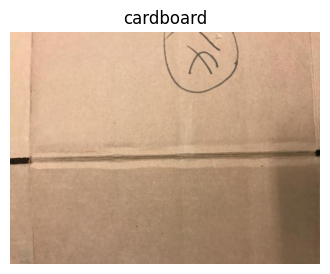

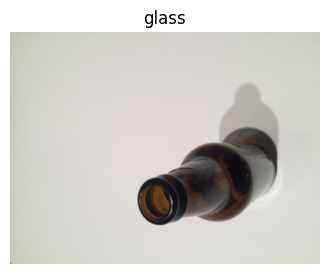

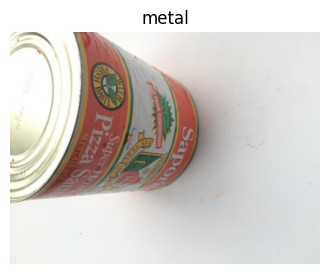

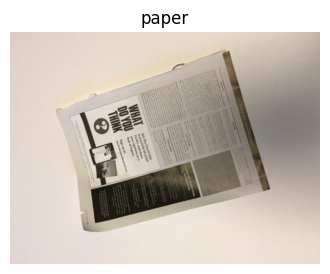

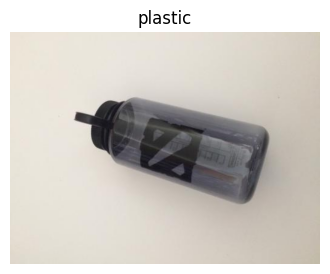

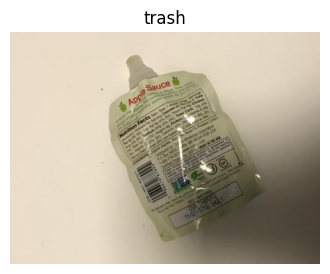

In [3]:
from PIL import Image

categories = os.listdir(dataset_path)

for category in categories:

    category_path = os.path.join(dataset_path, category)

    if os.path.isdir(category_path):

        image_name = os.listdir(category_path)[0]

        image_path = os.path.join(category_path, image_name)

        img = Image.open(image_path)

        plt.figure(figsize=(4,4))
        plt.imshow(img)
        plt.title(category)
        plt.axis("off")
        plt.show()

In [4]:
X = []
y = []

IMG_SIZE = 128

for category in os.listdir(dataset_path):

    category_path = os.path.join(dataset_path, category)

    if os.path.isdir(category_path):

        for image_name in os.listdir(category_path):

            image_path = os.path.join(category_path, image_name)

            try:

                img = cv2.imread(image_path)

                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                gray = cv2.cvtColor(
                    img,
                    cv2.COLOR_BGR2GRAY
                )

                features = hog(
                    gray,
                    orientations=9,
                    pixels_per_cell=(8, 8),
                    cells_per_block=(2, 2),
                    block_norm="L2-Hys"
                )

                X.append(features)

                y.append(category)

            except:
                pass

In [5]:
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2527, 8100)
y shape: (2527,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 2021
Testing Samples: 506


In [7]:
svm = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    class_weight="balanced",
    probability=True
)

svm.fit(X_train, y_train)

print("Training Complete!")

Training Complete!


In [8]:
predictions = svm.predict(X_test)

In [9]:
accuracy = accuracy_score(
    y_test,
    predictions
)

print(
    f"Accuracy: {accuracy:.4f}"
)

Accuracy: 0.6522


In [10]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

   cardboard       0.72      0.70      0.71        81
       glass       0.57      0.63      0.60       100
       metal       0.63      0.63      0.63        82
       paper       0.74      0.77      0.75       119
     plastic       0.56      0.56      0.56        97
       trash       1.00      0.44      0.62        27

    accuracy                           0.65       506
   macro avg       0.70      0.62      0.64       506
weighted avg       0.66      0.65      0.65       506



In [11]:
with open(
    "../model/waste_classifier.pkl",
    "wb"
) as f:

    pickle.dump(
        svm,
        f
    )

print(
    "SVM model saved successfully!"
)

SVM model saved successfully!


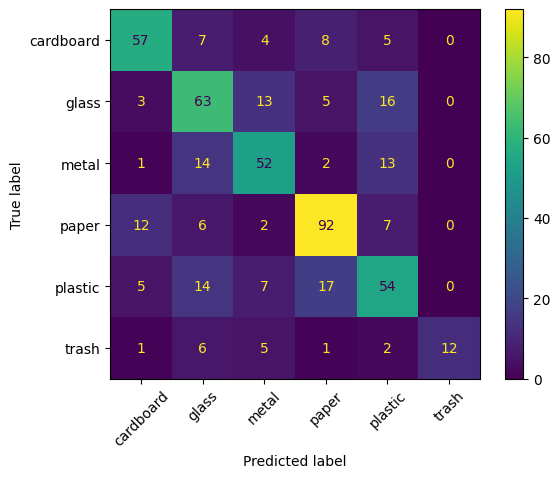

In [12]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    xticks_rotation=45
)

plt.show()